In [1]:
import numpy as np
import gamry_parser
import glob
from pathlib import Path
import os
import re
from pyDRTtools.runs import EIS_object, simple_run, BHT_run
import matplotlib.pyplot as plt
%matplotlib inline

Initializing pyDRTtools from C:\pea\code\drt_correct\.venv\lib\site-packages
['C:\\Users\\Alexa\\AppData\\Roaming\\uv\\python\\cpython-3.9-windows-x86_64-none\\python39.zip', 'C:\\Users\\Alexa\\AppData\\Roaming\\uv\\python\\cpython-3.9-windows-x86_64-none\\DLLs', 'C:\\Users\\Alexa\\AppData\\Roaming\\uv\\python\\cpython-3.9-windows-x86_64-none\\lib', 'C:\\Users\\Alexa\\AppData\\Roaming\\uv\\python\\cpython-3.9-windows-x86_64-none', 'C:\\Users\\Alexa\\AppData\\Local\\uv\\cache\\builds-v0\\.tmpeNXk0z', '', 'C:\\Users\\Alexa\\AppData\\Local\\uv\\cache\\builds-v0\\.tmpeNXk0z\\lib\\site-packages', 'C:\\Users\\Alexa\\AppData\\Local\\uv\\cache\\archive-v0\\5fTWzWnOYqtmDGrXV13Ve\\Lib\\site-packages', 'C:\\Users\\Alexa\\AppData\\Local\\uv\\cache\\archive-v0\\5fTWzWnOYqtmDGrXV13Ve\\Lib\\site-packages\\win32', 'C:\\Users\\Alexa\\AppData\\Local\\uv\\cache\\archive-v0\\5fTWzWnOYqtmDGrXV13Ve\\Lib\\site-packages\\win32\\lib', 'C:\\Users\\Alexa\\AppData\\Local\\uv\\cache\\archive-v0\\5fTWzWnOYqtmDGrXV1

In [2]:
main_dir = Path(r"C:\Users\Alexa\Desktop\PEA\EIS_data\NaCl")
patterns = ['*_168H.DTA']
file_list = []

for p in patterns:
    file_list.extend(list(main_dir.rglob(p)))
file_list.sort(key=lambda x: int(re.search(r'(\d+)H', x.name).group(1)))
    
all_datasets = []

for filename in file_list:
    parser = gamry_parser.GamryParser()
    parser.load(filename)
    data = parser.curves[0]
    original_eis_data = {
        'name': filename.stem,
        'Zreal':data['Zreal'].values,
        'Zimag':data['Zimag'].values,
        'Z_data':data['Zreal'].values + 1j*data['Zimag'].values,
        'Zmod':data['Zmod'].values,
        'Zphz':data['Zphz'].values,
        'Freq':data['Freq'].values,
        'circuit':None,
        'Z_fit':None,
        'chi_sq': None
    }

    eis_data = {
        'name': filename.stem,
        'Zreal':None,
        'Zimag':None,
        'Zmod':None,
        'Zphz':None,
        'Z_data':None,
        'Freq':None,
        'circuit':None,
        'Z_fit':None,
        'chi_sq': None
    }
    
    all_datasets.append({"eis_data":eis_data, "original_eis_data":original_eis_data})

In [3]:
entry = EIS_object(all_datasets[0]['original_eis_data']['Freq'], all_datasets[0]['original_eis_data']['Zreal'], all_datasets[0]['original_eis_data']['Zimag'])


# 3. Execute the DRT deconvolution
# This function updates 'entry' with the results and returns it
processed_entry = simple_run(
    entry, 
    rbf_type='Gaussian', 
    data_used='Combined Re-Im Data', 
    induct_used=0,             # 1 = consider inductance
    der_used='1st order', 
    cv_type='GCV',             # Automatically finds the best lambda
    reg_param=1e-3             # Starting guess for lambda
)

# 4. Access the calculated results directly
drt_gamma = processed_entry.gamma
drt_tau = processed_entry.out_tau_vec
recovered_R = processed_entry.R
recovered_L = processed_entry.L

print(f"Analysis complete. Recovered Resistance: {recovered_R:.4f} Ohms")

Optimization terminated successfully    (Exit mode 0)
            Current function value: 1783.3646671441998
            Iterations: 5
            Function evaluations: 49
            Gradient evaluations: 5
GCV
The value of the regularization parameter is [1.00874466e-07]
     pcost       dcost       gap    pres   dres
 0: -8.6952e+08 -8.9807e+08  3e+07  4e+01  3e-02
 1: -8.7275e+08 -8.9015e+08  2e+07  2e+01  2e-02
 2: -8.7430e+08 -8.7585e+08  2e+06  1e+00  8e-04
 3: -8.7437e+08 -8.7496e+08  6e+05  4e-01  3e-04
 4: -8.7440e+08 -8.7470e+08  3e+05  1e-02  1e-05
 5: -8.7443e+08 -8.7463e+08  2e+05  6e-03  5e-06
 6: -8.7445e+08 -8.7448e+08  3e+04  8e-04  6e-07
 7: -8.7446e+08 -8.7446e+08  9e+03  8e-05  6e-08
 8: -8.7446e+08 -8.7446e+08  1e+03  7e-06  5e-09
 9: -8.7446e+08 -8.7446e+08  2e+02  6e-07  4e-10
10: -8.7446e+08 -8.7446e+08  4e+01  6e-12  4e-16
Optimal solution found.
Analysis complete. Recovered Resistance: 50.7108 Ohms


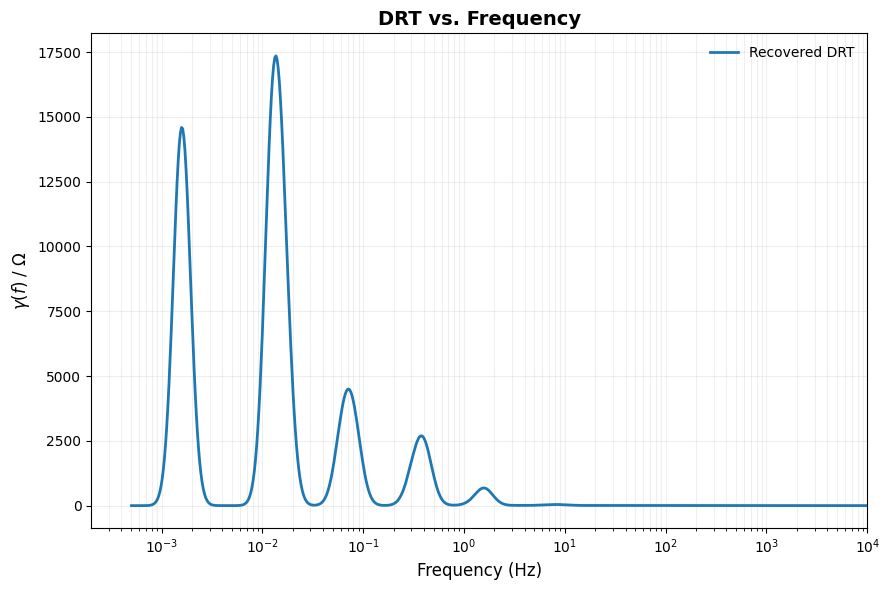

In [11]:
# 1. Convert tau to frequency (Hz)
# Note: drt_tau must be in seconds
drt_freq = 1 / (2 * np.pi * drt_tau)

plt.figure(figsize=(9, 6), dpi=100)

# 2. Plot vs Frequency
# We use drt_freq as the x-axis
plt.plot(drt_freq, drt_gamma, color='#1f77b4', linewidth=2, label='Recovered DRT')

# --- Formatting ---

# Use LaTeX for professional units and symbols
plt.xlabel('Frequency (Hz)', fontsize=12)
plt.ylabel(r'$\gamma(f)$ / $\Omega$', fontsize=12)
plt.title('DRT vs. Frequency', fontsize=14, fontweight='bold')

# Log scale is still mandatory because frequency spans several decades
plt.xscale('log')

# Specialized grid for log plots
plt.grid(True, which="both", ls="-", alpha=0.2)

# Ensure the y-axis starts at 0
plt.ylim(bottom=-max(drt_gamma)*0.05) 
plt.xlim(right=1e4)

plt.legend(frameon=False)
plt.tight_layout()

plt.show()

In [5]:
processed_entry_BHT = BHT_run(entry, rbf_type='C2 Matern',coeff=0.4)

sigma_n; sigma_beta; sigma_lambda
1.00777e+00     381.356896     0.348975 
-3.26250e+00     381.356896     26.367687 
-3.31717e+00     636.866725     26.700518 
-3.43691e+00     1195.055598     27.429579 
-3.69291e+00     2388.034433     28.988206 
-4.25982e+00     5029.805012     32.439768 
-5.56536e+00     11113.562961     40.388408 
-6.87117e+00     17198.562889     48.338672 
-8.60087e+00     25258.881795     58.869759 
-1.06455e+01     34786.797962     71.318312 
-1.31670e+01     46536.590168     86.669824 
-1.62178e+01     60753.589474     105.244827 
-1.99271e+01     78038.579058     127.828267 
-2.44102e+01     98929.312982     155.122736 
-2.98233e+01     124154.107759     188.079807 
-3.62993e+01     154332.257968     227.508609 
-4.39614e+01     190036.939027     274.158015 
-5.29773e+01     232050.563209     329.050275 
-6.28738e+01     278167.941012     389.304232 
-7.44671e+01     332192.018890     459.888566 
-8.62272e+01     386993.703810     531.488872 
-9.67107e+01   

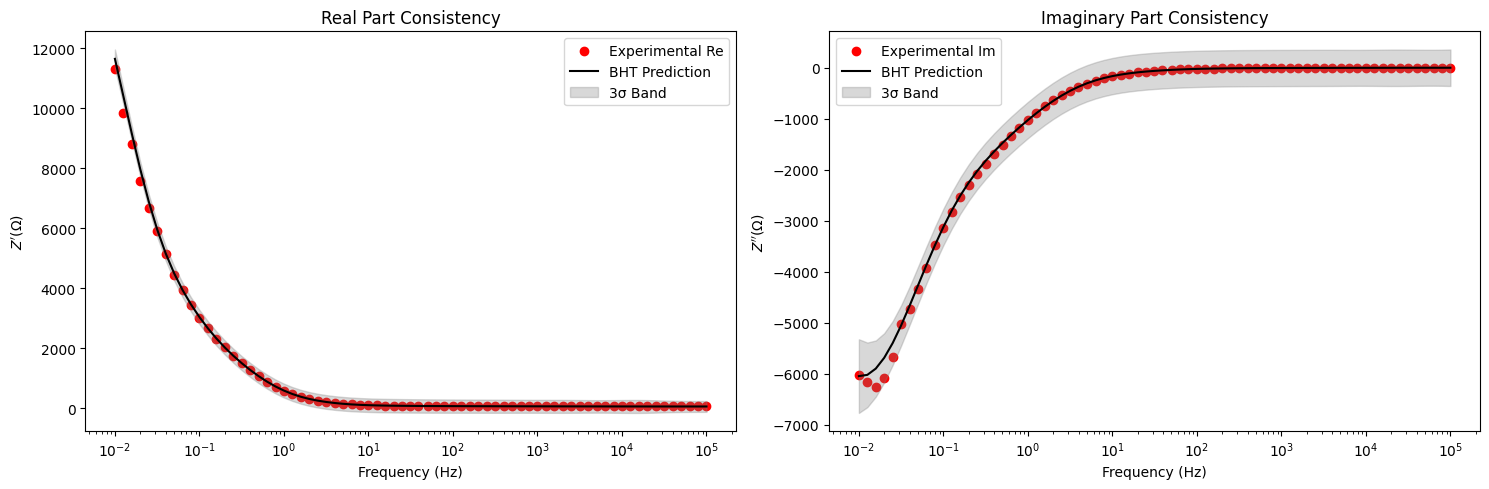

In [6]:
# Create a figure with 2 subplots side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# --- Left Subplot: Real Part (Z') ---
# Experimental data
ax1.scatter(processed_entry_BHT.freq, processed_entry_BHT.b_re, color='red', label='Experimental Re')

# BHT Prediction
ax1.plot(processed_entry_BHT.freq, processed_entry_BHT.mu_Z_H_re_agm, color='black', label='BHT Prediction')

# Uncertainty band
lower_re = processed_entry_BHT.mu_Z_H_re_agm - 3 * processed_entry_BHT.band_re_agm
upper_re = processed_entry_BHT.mu_Z_H_re_agm + 3 * processed_entry_BHT.band_re_agm
ax1.fill_between(processed_entry_BHT.freq, lower_re, upper_re, color='gray', alpha=0.3, label='3σ Band')

ax1.set_xscale('log')
ax1.set_xlabel('Frequency (Hz)')
ax1.set_ylabel(r"$Z' (\Omega)$")
ax1.set_title('Real Part Consistency')
ax1.legend()

# --- Right Subplot: Imaginary Part (Z'') ---
# Experimental data
ax2.scatter(processed_entry_BHT.freq, processed_entry_BHT.b_im, color='red', label='Experimental Im')

# BHT Prediction
ax2.plot(processed_entry_BHT.freq, processed_entry_BHT.mu_Z_H_im_agm, color='black', label='BHT Prediction')

# Uncertainty band
lower_im = processed_entry_BHT.mu_Z_H_im_agm - 3 * processed_entry_BHT.band_im_agm
upper_im = processed_entry_BHT.mu_Z_H_im_agm + 3 * processed_entry_BHT.band_im_agm
ax2.fill_between(processed_entry_BHT.freq, lower_im, upper_im, color='gray', alpha=0.3, label='3σ Band')

ax2.set_xscale('log')
ax2.set_xlabel('Frequency (Hz)')
ax2.set_ylabel(r"$Z'' (\Omega)$")
ax2.set_title('Imaginary Part Consistency')
ax2.legend()

plt.tight_layout()
plt.show()

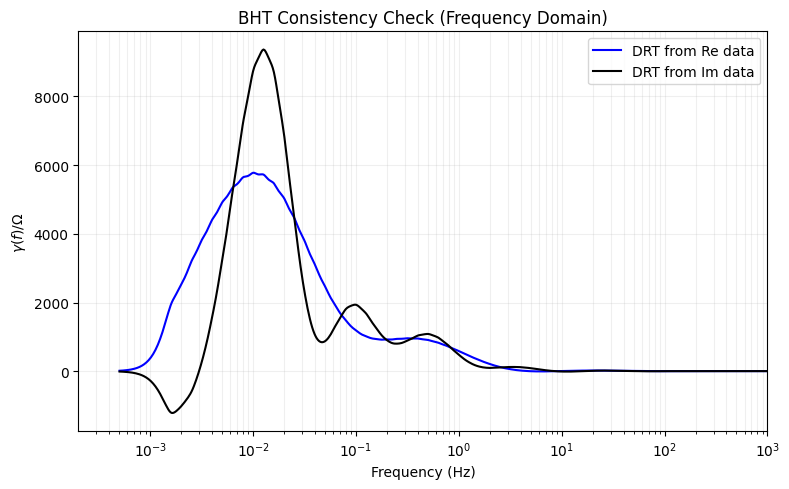

In [13]:
# 1. Convert the BHT tau vector to frequency (Hz)
bht_freq_vec = 1 / (2 * np.pi * processed_entry_BHT.out_tau_vec)

plt.figure(figsize=(8, 5))

# 2. Plot using frequency as the x-axis
plt.semilogx(bht_freq_vec, processed_entry_BHT.mu_gamma_fine_re, 'b', label='DRT from Re data')
plt.semilogx(bht_freq_vec, processed_entry_BHT.mu_gamma_fine_im, 'k', label='DRT from Im data')

# 3. Add the X-limit maximum (e.g., 10^6 for 1 MHz)
plt.xlim(right=1e3) 

# Update labels for the frequency domain
plt.xlabel('Frequency (Hz)')
plt.ylabel(r'$\gamma(f) / \Omega$')
plt.title('BHT Consistency Check (Frequency Domain)')

plt.grid(True, which="both", ls="-", alpha=0.2)
plt.legend()
plt.tight_layout()
plt.show()

In [8]:
scores = processed_entry_BHT.out_scores

print("\n" + "="*40)
print(f"{'BHT CONSISTENCY CHECK':^40}")
print("="*40)
print(f"{'Metric':<20} | {'Value':>15}")
print("-" * 40)

for metric, value in scores.items():
    # Force the value to a float in case it's a 1-element numpy array
    try:
        # .item() works if it's a numpy array; float() works if it's already a number
        clean_value = float(value.item()) if hasattr(value, 'item') else float(value)
        
        label = f"{metric}" if metric == 's_mu_im' else metric
        print(f"{label:<20} | {clean_value:>15.4f}")
    except:
        # Fallback if something is truly weird
        print(f"{metric:<20} | {str(value):>15}")

print("="*40)


         BHT CONSISTENCY CHECK          
Metric               |           Value
----------------------------------------
s_res_re             | [0.92957746 0.92957746 0.94366197]
s_res_im             | [0.95774648 0.98591549 1.        ]
s_mu_re              |          0.9792
s_mu_im              |          0.9843
s_HD_re              |          0.7595
s_HD_im              |          0.5933
s_JSD_re             |          0.8898
s_JSD_im             |          0.7632
